# Channel, Discount, and Cohort Quality

Recreates channel quality, discount sensitivity, marketplace comparison, and discount deep-dive checks from Gold/Silver.


In [1]:
from pathlib import Path
import os
import warnings
warnings.filterwarnings("ignore")

_BOOT_ROOT = Path.cwd()
_MPL_DIR = (_BOOT_ROOT / "outputs" / ".matplotlib") if _BOOT_ROOT.name == "notebooks" else (_BOOT_ROOT / "notebooks" / "outputs" / ".matplotlib")
_MPL_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(_MPL_DIR))
os.environ.setdefault("XDG_CACHE_HOME", str(_MPL_DIR.parent / ".cache"))

import numpy as np
import pandas as pd
import matplotlib
if os.environ.get("NOTEBOOK_VALIDATION") == "1":
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

try:
    from IPython.display import display, Markdown
except Exception:
    def display(x): print(x)
    def Markdown(x): return x

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = Path.cwd().resolve()

SILVER = PROJECT_ROOT / "data" / "silver"
GOLD = PROJECT_ROOT / "data" / "gold"
LEGACY_OUT = PROJECT_ROOT / "EDA" / "outputs"
NB_OUT = PROJECT_ROOT / "notebooks" / "outputs"
CHART_OUT = NB_OUT / "charts"
NB_OUT.mkdir(parents=True, exist_ok=True)
CHART_OUT.mkdir(parents=True, exist_ok=True)

ANALYSIS_DATE = pd.Timestamp("2026-04-30", tz="UTC")
MARGIN = 0.40

TEAL = "#2DC4A2"
NAVY = "#1A2E44"
SLATE = "#4A6274"
ORANGE = "#F07D3E"
RED = "#E84545"
GOLD_C = "#F7B731"
LILAC = "#9B72CF"
LIGHT_BG = "#F8F9FA"
CAT_COLORS = [TEAL, NAVY, ORANGE, GOLD_C, SLATE, RED, LILAC]
plt.rcParams.update({
    "figure.facecolor": LIGHT_BG,
    "axes.facecolor": LIGHT_BG,
    "axes.edgecolor": "#E2E8ED",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#E2E8ED",
    "axes.labelcolor": NAVY,
    "axes.titlecolor": NAVY,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "xtick.color": SLATE,
    "ytick.color": SLATE,
    "legend.frameon": False,
    "font.family": ["DejaVu Sans"],
})

def money(x):
    return f"S${x:,.0f}"

def pct(x):
    return f"{x:.1%}"

RECREATED_CHARTS = []

def save_chart(fig, name):
    RECREATED_CHARTS.append(name)
    if os.environ.get("NOTEBOOK_VALIDATION") == "1":
        fig.canvas.draw()
    else:
        display(fig)
    plt.close(fig)
    print(f"rendered inline: {name}")
    return name

def load_marts():
    orders = pd.read_parquet(SILVER / "orders.parquet").copy()
    customers = pd.read_parquet(GOLD / "customers.parquet").copy()
    lines = pd.read_parquet(GOLD / "order_lines_enriched.parquet").copy()
    recharge_orders = pd.read_parquet(GOLD / "recharge_orders_enriched.parquet").copy()
    silver = {
        "discounts": pd.read_parquet(SILVER / "discounts.parquet"),
        "products": pd.read_parquet(SILVER / "products.parquet"),
        "campaigns": pd.read_parquet(SILVER / "campaigns.parquet"),
        "recharge_checkout": pd.read_parquet(SILVER / "recharge_checkout_items.parquet"),
        "recharge_recurring": pd.read_parquet(SILVER / "recharge_recurring_items.parquet"),
        "recharge_churned": pd.read_parquet(SILVER / "recharge_churned.parquet"),
        "recharge_reactivated": pd.read_parquet(SILVER / "recharge_reactivated.parquet"),
        "recharge_orders": pd.read_parquet(SILVER / "recharge_orders.parquet"),
    }
    orders["order_date"] = pd.to_datetime(orders["order_date"], utc=True)
    customers["first_order_date"] = pd.to_datetime(customers["first_order_date"], utc=True)
    customers["last_order_date"] = pd.to_datetime(customers["last_order_date"], utc=True)
    customers["second_order_date"] = pd.to_datetime(customers["second_order_date"], utc=True, errors="coerce")
    lines["order_date"] = pd.to_datetime(lines["order_date"], utc=True)

    orders["primary_revenue_sgd"] = pd.to_numeric(orders["order_revenue_sgd"], errors="coerce").fillna(0)
    orders["legacy_total_incl_shipping_sgd"] = pd.to_numeric(orders["order_total_incl_shipping_sgd"], errors="coerce").fillna(0)
    orders["Price: Total"] = orders["legacy_total_incl_shipping_sgd"]
    orders["Price: Total Discount"] = pd.to_numeric(orders["order_discount_sgd"], errors="coerce").fillna(0)
    orders["Price: Total Shipping"] = pd.to_numeric(orders["shipping_revenue_sgd"], errors="coerce").fillna(0)
    orders["revenue_basis_delta_sgd"] = orders["legacy_total_incl_shipping_sgd"] - orders["primary_revenue_sgd"]

    customers["total_revenue"] = pd.to_numeric(customers["total_revenue_sgd"], errors="coerce").fillna(0)
    customers["total_discount"] = pd.to_numeric(customers["total_discount_sgd"], errors="coerce").fillna(0)
    customers["first_product_cat"] = customers["first_product_category"]
    customers["is_repeat"] = customers["is_repeat"].astype(bool)

    for col in ["Line: Quantity", "Line: Price", "Line: Discount", "Line: Total"]:
        if col in lines.columns:
            lines[col] = pd.to_numeric(lines[col], errors="coerce").fillna(0)
    return orders, customers, lines, recharge_orders, silver

orders, customers, lines, recharge_orders, silver = load_marts()
print(f"Loaded marts: {len(orders):,} orders, {len(customers):,} customers, {len(lines):,} enriched lines")
print("Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.")


Loaded marts: 27,350 orders, 13,780 customers, 50,963 enriched lines
Primary revenue excludes shipping. Legacy comparability uses order_total_incl_shipping_sgd.


## Channel Quality and Discount Sensitivity


In [2]:
channel_quality = customers.groupby("first_channel").agg(customers=("customer_id", "count"), repeaters=("is_repeat", "sum"), avg_ltv=("total_revenue", "mean"), avg_orders=("total_orders", "mean"), avg_lifespan_days=("lifespan_days", "mean"), pct_subscribed=("ever_subscribed", "mean"), pct_discounted=("ever_discounted", "mean"), median_days_2nd=("days_to_second", "median")).assign(repeat_rate=lambda d: d.repeaters / d.customers).sort_values("avg_ltv", ascending=False)
display(channel_quality)
channel_quality.to_csv(NB_OUT / "03_channel_quality.csv")

disc_sens = customers.groupby("ever_discounted").agg(customers=("customer_id", "count"), repeat_rate=("is_repeat", "mean"), avg_ltv=("total_revenue", "mean"), avg_orders=("total_orders", "mean"), avg_lifespan_days=("lifespan_days", "mean"), pct_subscribed=("ever_subscribed", "mean"), median_days_2nd=("days_to_second", "median"))
disc_sens.index = disc_sens.index.map({True:"Discounted (any order)", False:"Full-price only"})
display(disc_sens)
disc_sens.to_csv(NB_OUT / "03_discount_sensitivity.csv")

first_order = orders.sort_values("order_date").groupby("customer_id").first().reset_index()[["customer_id", "has_discount", "Price: Total Discount", "primary_revenue_sgd", "legacy_total_incl_shipping_sgd"]]
first_order = first_order.rename(columns={"has_discount":"first_discounted", "Price: Total Discount":"first_disc_amt", "primary_revenue_sgd":"first_order_revenue_sgd"})
df = customers.merge(first_order, on="customer_id", how="left")
df["disc_depth"] = (df.first_disc_amt.fillna(0) / df.first_order_revenue_sgd.replace(0, np.nan)).fillna(0).clip(0, 1)
bins = [-0.001, 0, 0.05, 0.10, 0.20, 0.30, 0.50, 1.01]
labels = ["0% (full price)","1-5%","6-10%","11-20%","21-30%","31-50%","51%+"]
df["discount_bin"] = pd.cut(df.disc_depth, bins=bins, labels=labels)
depth = df.groupby("discount_bin", observed=True).agg(customers=("customer_id", "count"), repeat_rate=("is_repeat", "mean"), avg_ltv=("total_revenue", "mean"), avg_first_order_revenue=("first_order_revenue_sgd", "mean")).reset_index()
display(depth)
depth.to_csv(NB_OUT / "03_discount_depth_bins.csv", index=False)


,customers,repeaters,avg_ltv,avg_orders,avg_lifespan_days,pct_subscribed,pct_discounted,median_days_2nd,repeat_rate
first_channel,,,,,,,,,
Subscription,4275,1747,338.748876,2.270409,172.854035,0.188070,0.387602,59.0,0.408655
Direct / Organic,6920,2320,195.523899,1.984393,120.879913,0.038439,0.393786,42.0,0.335260
Marketplace,2126,306,114.312003,1.537629,13.849012,0.000000,0.799624,43.0,0.143932
Affiliate,26,5,90.739615,1.346154,7.230769,0.038462,1.000000,38.0,0.192308
Paid Search,3,1,85.800000,1.333333,28.666667,0.000000,0.000000,86.0,0.333333
Paid Social,382,74,69.660759,1.408377,19.369110,0.060209,0.212042,18.0,0.193717
Email,48,6,48.086307,1.375000,18.041667,0.020833,0.770833,29.5,0.125000


,customers,repeat_rate,avg_ltv,avg_orders,avg_lifespan_days,pct_subscribed,median_days_2nd
ever_discounted,,,,,,,
Full-price only,7554,0.291501,199.989356,1.733122,65.464257,0.047392,36.0
Discounted (any order),6226,0.362512,251.368412,2.290074,179.714905,0.118375,60.0


,discount_bin,customers,repeat_rate,avg_ltv,avg_first_order_revenue
0,0% (full price),9409,0.364119,270.979392,87.947297
1,1-5%,112,0.133929,118.178506,85.017530
2,6-10%,423,0.271868,135.436177,85.622192
3,11-20%,1291,0.250968,115.417088,74.318274
4,21-30%,430,0.251163,156.331612,105.544132
5,31-50%,1200,0.236667,151.256822,97.917877
6,51%+,915,0.204372,63.207089,41.821967


## Discount Code Taxonomy and Marketplace Comparison


In [3]:
discounts = silver["discounts"].copy()
discounts["code_upper"] = discounts.Name.astype(str).str.upper().fillna("")
def classify_code(code):
    c = str(code).upper()
    if "WELCOME" in c or "FIRST" in c or "NEW" in c: return "Welcome / New Customer"
    if "AFFILIATE" in c: return "Affiliate"
    if any(x in c for x in ["HYROX","POPUP","EVENT","GYM","FIT"]): return "Event / Partnership"
    if any(x in c for x in ["BUNDLE","KIT","COMBO","SET"]): return "Bundle"
    if any(x in c for x in ["FRIEND","REFER","REF"]): return "Referral"
    if any(x in c for x in ["FLASH","SALE","PROMO","OFF"]): return "Flash / Sale"
    return "Other"
discounts["code_type"] = discounts.code_upper.apply(classify_code)
discounts["times_used"] = pd.to_numeric(discounts["Times Used In Total"], errors="coerce").fillna(0)
discounts["value"] = pd.to_numeric(discounts["Value"], errors="coerce")
taxonomy = discounts[discounts.times_used > 0].groupby("code_type").agg(n_codes=("Name", "count"), total_redemptions=("times_used", "sum"), avg_discount_val=("value", "mean")).sort_values("total_redemptions", ascending=False)
display(taxonomy)
taxonomy.to_csv(NB_OUT / "03_discount_code_taxonomy.csv")

website_channels = ["Direct / Organic", "Paid Social", "Paid Search", "Email", "Affiliate"]
marketplace = customers[customers.first_channel == "Marketplace"]
website = customers[customers.first_channel.isin(website_channels)]
marketplace_compare = pd.DataFrame([
    {"segment":"Marketplace", "customers":len(marketplace), "repeat_rate":marketplace.is_repeat.mean(), "avg_ltv":marketplace.total_revenue.mean(), "avg_orders":marketplace.total_orders.mean(), "pct_subscribed":marketplace.ever_subscribed.mean()},
    {"segment":"Own Website", "customers":len(website), "repeat_rate":website.is_repeat.mean(), "avg_ltv":website.total_revenue.mean(), "avg_orders":website.total_orders.mean(), "pct_subscribed":website.ever_subscribed.mean()},
])
display(marketplace_compare)
marketplace_compare.to_csv(NB_OUT / "03_marketplace_vs_website.csv", index=False)


,n_codes,total_redemptions,avg_discount_val
code_type,,,
Other,134,2013,-45.123881
Bundle,4,359,NaN
Welcome / New Customer,1,154,-10.000000
Affiliate,7,138,-50.142857
Flash / Sale,7,96,-20.714286
Event / Partnership,6,17,-70.000000
Referral,4,4,-30.000000


,segment,customers,repeat_rate,avg_ltv,avg_orders,pct_subscribed
0,Marketplace,2126,0.143932,114.312003,1.537629,0.000000
1,Own Website,7379,0.326060,187.635257,1.948096,0.039436


## Slide and Revenue Basis Checks


In [4]:
legacy_delta = orders.revenue_basis_delta_sgd.sum()
slide_checks = pd.DataFrame([
    {"metric":"Gold revenue excludes shipping", "value": orders.primary_revenue_sgd.sum()},
    {"metric":"Legacy revenue includes shipping", "value": orders.legacy_total_incl_shipping_sgd.sum()},
    {"metric":"Revenue basis delta", "value": legacy_delta},
    {"metric":"All-market repeat rate", "value": customers.is_repeat.mean()},
    {"metric":"Subscriber LTV uplift", "value": sub_uplift if 'sub_uplift' in globals() else np.nan},
])
# compute subscriber uplift locally
sub = customers[customers.ever_subscribed]
non = customers[~customers.ever_subscribed]
slide_checks.loc[slide_checks.metric == "Subscriber LTV uplift", "value"] = sub.total_revenue.mean() / non.total_revenue.mean() - 1
display(slide_checks)
slide_checks.to_csv(NB_OUT / "03_slide_and_revenue_basis_checks.csv", index=False)


,metric,value
0,Gold revenue excludes shipping,3.075739e+06
1,Legacy revenue includes shipping,3.112952e+06
2,Revenue basis delta,3.721246e+04
3,All-market repeat rate,3.235849e-01
4,Subscriber LTV uplift,1.680793e+00


## Discount and Channel Charts


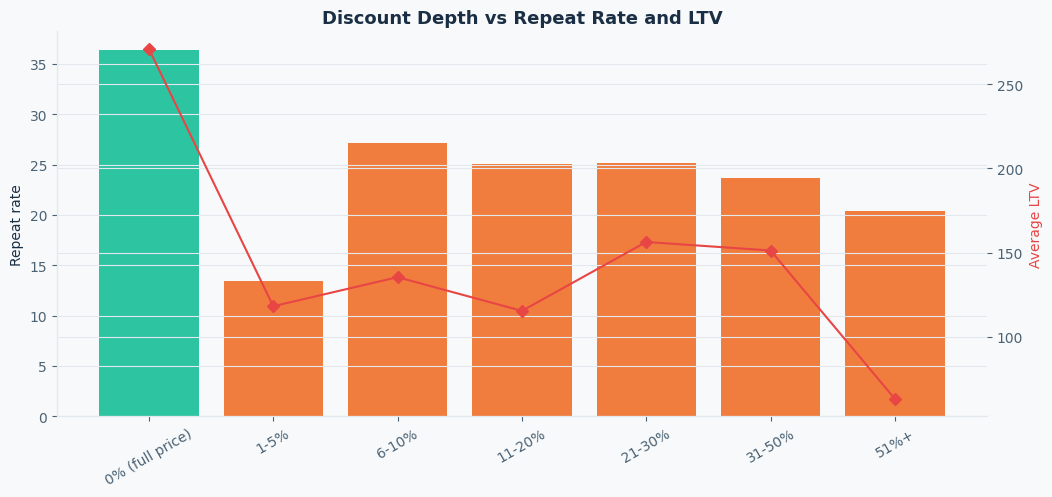

rendered inline: 05a_discount_depth_impact


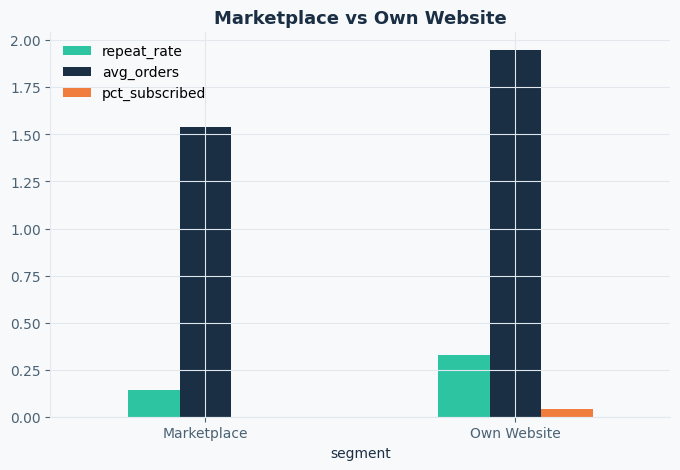

rendered inline: 05b_marketplace_vs_website


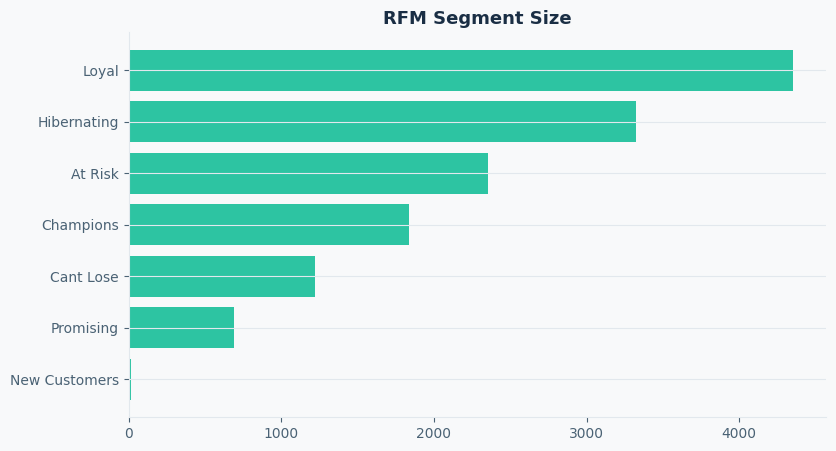

rendered inline: 05c_rfm_segments


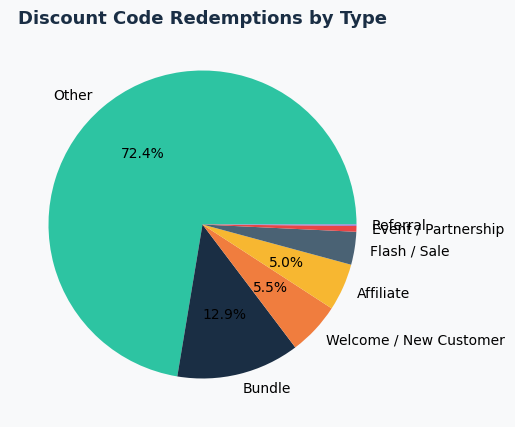

rendered inline: 05d_discount_code_taxonomy


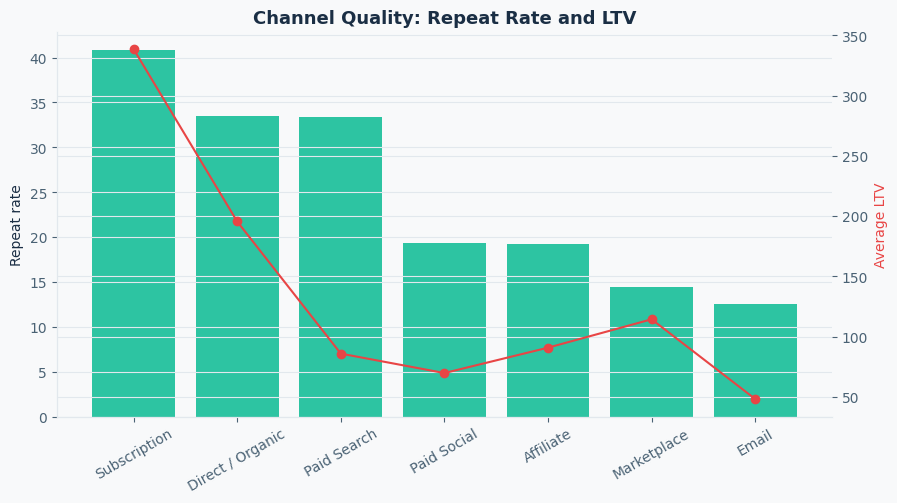

rendered inline: 06a_channel_quality_dual


'06a_channel_quality_dual'

In [5]:
fig, ax1 = plt.subplots(figsize=(12, 5))
dd = depth.copy()
ax1.bar(dd.discount_bin.astype(str), dd.repeat_rate * 100, color=[TEAL] + [ORANGE] * (len(dd)-1))
ax1.set_title("Discount Depth vs Repeat Rate and LTV")
ax1.set_ylabel("Repeat rate")
ax1.tick_params(axis="x", rotation=30)
ax2 = ax1.twinx()
ax2.plot(dd.discount_bin.astype(str), dd.avg_ltv, color=RED, marker="D")
ax2.set_ylabel("Average LTV", color=RED)
save_chart(fig, "05a_discount_depth_impact")

fig, ax = plt.subplots(figsize=(8, 5))
mc = marketplace_compare.set_index("segment")
mc[["repeat_rate", "avg_orders", "pct_subscribed"]].plot(kind="bar", ax=ax, color=[TEAL, NAVY, ORANGE])
ax.set_title("Marketplace vs Own Website")
ax.tick_params(axis="x", rotation=0)
save_chart(fig, "05b_marketplace_vs_website")

# RFM recreation for chart context
rfm = customers.copy()
for col in ["recency_days", "total_orders", "total_revenue"]:
    rfm[col] = pd.to_numeric(rfm[col], errors="coerce").fillna(0)
def score_col(series, ascending=True, n=4):
    ranked = series.rank(method="first", ascending=ascending)
    bins = np.linspace(ranked.min() - 0.001, ranked.max() + 0.001, n + 1)
    return pd.cut(ranked, bins=bins, labels=list(range(1, n + 1))).astype(int)
def seg(r, f, m):
    if r == 4 and f >= 3 and m >= 3: return "Champions"
    if r >= 3 and f >= 2: return "Loyal"
    if r == 4 and f == 1: return "New Customers"
    if r == 3 and f == 1: return "Promising"
    if r <= 2 and f >= 3: return "At Risk"
    if r == 1 and f >= 2: return "Cant Lose"
    if r <= 2 and f <= 2: return "Hibernating"
    return "Others"
rfm["R"] = score_col(rfm.recency_days, ascending=False); rfm["F"] = score_col(rfm.total_orders); rfm["M"] = score_col(rfm.total_revenue)
rfm["segment"] = rfm.apply(lambda x: seg(x.R, x.F, x.M), axis=1)
rfm_seg = rfm.groupby("segment").agg(n=("customer_id", "count"), avg_ltv=("total_revenue", "mean")).sort_values("n", ascending=False)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(rfm_seg.index[::-1], rfm_seg.n[::-1], color=TEAL)
ax.set_title("RFM Segment Size")
save_chart(fig, "05c_rfm_segments")

fig, ax = plt.subplots(figsize=(8, 5))
ax.pie(taxonomy.total_redemptions, labels=taxonomy.index, autopct=lambda p: f"{p:.1f}%" if p > 4 else "", colors=CAT_COLORS)
ax.set_title("Discount Code Redemptions by Type")
save_chart(fig, "05d_discount_code_taxonomy")

fig, ax1 = plt.subplots(figsize=(10, 5))
cq = channel_quality.reset_index().sort_values("repeat_rate", ascending=False)
ax1.bar(cq.first_channel, cq.repeat_rate * 100, color=TEAL)
ax1.tick_params(axis="x", rotation=30)
ax1.set_ylabel("Repeat rate")
ax2 = ax1.twinx(); ax2.plot(cq.first_channel, cq.avg_ltv, color=RED, marker="o"); ax2.set_ylabel("Average LTV", color=RED)
ax1.set_title("Channel Quality: Repeat Rate and LTV")
save_chart(fig, "06a_channel_quality_dual")
